# Imputing missing cells with `LanguageModelImputer`

The imputer fills a missing cell by conditioning on the row's observed cells. A categorical cell is
**scored** over its observed levels and filled with the most likely one; a numeric cell is generated,
or scored over a grid of observed values under `discretization`. When a row has several holes they
are filled in a chain, each fill conditioning on the ones before it.

Here `bill_length_mm` and `island` are blanked together in 40% of the rows of the Palmer penguins
table, filled by the imputer and by a `KNNImputer` baseline, and compared to the hidden truth.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.metrics import ConfusionMatrixDisplay, root_mean_squared_error
from sklearn.preprocessing import OrdinalEncoder

from sklm import DiscretizationConfig, LanguageModelImputer, TrainingConfig, GenerationConfig

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

## Data

333 complete rows: four measurements and three categorical columns. The truth is kept aside to
score the fills.

In [2]:
NUM = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
CAT = ["island", "sex", "species"]
TARGETS = ["bill_length_mm", "island"]

frame = sns.load_dataset("penguins").dropna().reset_index(drop=True)[NUM + CAT]
island_levels = sorted(frame["island"].unique())

rng = np.random.default_rng(SEED)
mask = rng.random(len(frame)) < 0.4
corrupt = frame.copy()
corrupt.loc[mask, TARGETS] = np.nan
print(f"rows missing {TARGETS}: {int(mask.sum())} of {len(frame)}")

rows missing ['bill_length_mm', 'island']: 136 of 333


## Impute with the language model

`fit_transform` fine-tunes on the complete rows (`complete_rows_only=True`) and fills every `NaN`.
`island` is scored over its three levels; `candidate_scoring="sum"` ranks them by total rather than
mean per-token log-likelihood, so a level the tokenizer splits into more pieces is not favoured.
`bill_length_mm` is generated: `n_samples=6` draws per cell, averaged. With two holes in a row,
`cell_order="confidence"` fills the cell the model is most certain about first, and the other one
conditions on it.

In [3]:
lm_filled = LanguageModelImputer(
    backend="mlx",
    model="mlx-community/distilgpt2",
    precision="fp32",
    # training=TrainingConfig(epochs=40, batch_size=16),
    # discretization=DiscretizationConfig(bins=0.5, strategy='uniform', estimate='median'),
    generation=GenerationConfig(cell_order='confidence', n_samples=6, candidate_scoring='sum'),
    random_state=SEED,
    complete_rows_only=True,
).fit_transform(corrupt)
lm_filled["bill_length_mm"] = lm_filled["bill_length_mm"].astype(float)

HTML(value='')

## Baseline: KNN over ordinal-encoded columns

`KNNImputer` needs a numeric matrix: the categoricals are ordinal-encoded, imputed by the 5 nearest
neighbours, and the codes rounded back to levels.

In [4]:
def knn_impute(frame: pd.DataFrame, cat_cols: list[str], k: int = 5) -> pd.DataFrame:
    enc = OrdinalEncoder().fit(frame[cat_cols])
    filled = frame.copy()
    filled[cat_cols] = enc.transform(frame[cat_cols])
    filled[:] = KNNImputer(n_neighbors=k).fit_transform(filled.to_numpy(float))
    filled[cat_cols] = enc.inverse_transform(filled[cat_cols].round().to_numpy(copy=True))
    return filled


knn_filled = knn_impute(corrupt, CAT)

## Reconstruction on the hidden cells

RMSE for `bill_length_mm` (a mean fill scores the column's standard deviation) and accuracy for
`island` (a majority fill scores the majority rate).

In [5]:
truth_bill = frame.loc[mask, "bill_length_mm"].to_numpy()
truth_island = frame.loc[mask, "island"].to_numpy()

filled = {"language model": lm_filled, "KNN": knn_filled}
for name, f in filled.items():
    rmse = root_mean_squared_error(truth_bill, f.loc[mask, "bill_length_mm"].to_numpy(float))
    acc = float((f.loc[mask, "island"].to_numpy() == truth_island).mean())
    print(f"{name:16}  bill_length RMSE {rmse:.2f}   island accuracy {acc:.3f}")
print(
    f"{'naive fill':16}  bill_length RMSE {frame['bill_length_mm'].std():.2f}"
    f"   island accuracy {frame['island'].value_counts(normalize=True).max():.3f}"
)

language model    bill_length RMSE 2.92   island accuracy 0.757
KNN               bill_length RMSE 4.39   island accuracy 0.625
naive fill        bill_length RMSE 5.47   island accuracy 0.489


Confusion matrices for `island` and imputed-vs-true scatter for `bill_length_mm`:

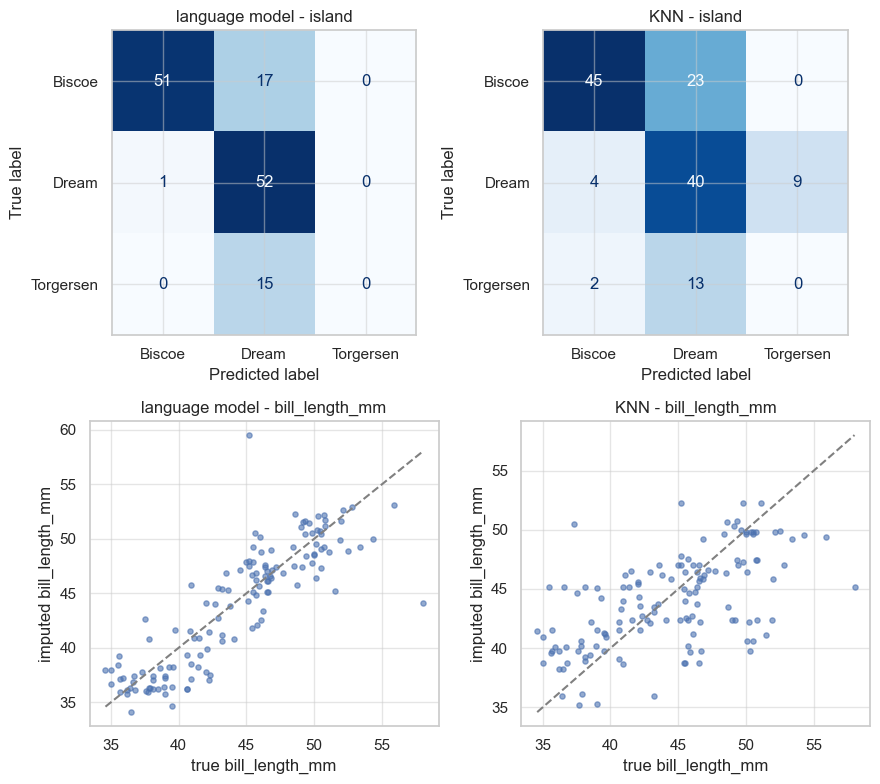

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for col, (name, f) in enumerate(filled.items()):
    ConfusionMatrixDisplay.from_predictions(
        truth_island, f.loc[mask, "island"].to_numpy(), labels=island_levels,
        ax=axes[0, col], colorbar=False, cmap="Blues",
    )
    axes[0, col].set_title(f"{name} - island")
    pred_bill = f.loc[mask, "bill_length_mm"].to_numpy(float)
    lo, hi = truth_bill.min(), truth_bill.max()
    axes[1, col].scatter(truth_bill, pred_bill, s=14, alpha=0.6)
    axes[1, col].plot([lo, hi], [lo, hi], ls="--", color="grey")
    axes[1, col].set_xlabel("true bill_length_mm")
    axes[1, col].set_ylabel("imputed bill_length_mm")
    axes[1, col].set_title(f"{name} - bill_length_mm")
plt.tight_layout()
plt.show()